In [48]:
#importar librería pandas

In [49]:
import pandas as pd

Lectura del archivo, head, tail, sample, describe.

In [50]:
df = pd.read_csv('vgsales.csv')

In [51]:
df.head(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [52]:
df.tail(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [53]:
df.sample(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
1495,1497,Madden NFL 97,PS,1996.0,Sports,Electronic Arts,0.73,0.50,0.0,0.09,1.32
3071,3073,Street Fighter Anniversary Collection,PS2,2004.0,Fighting,Capcom,0.32,0.25,0.0,0.08,0.66
5873,5875,Jonas,DS,2009.0,Adventure,Disney Interactive Studios,0.28,0.00,0.0,0.02,0.30
15875,15878,Turbo: Super Stunt Squad,3DS,2013.0,Sports,D3Publisher,0.00,0.01,0.0,0.00,0.02
14485,14488,Ducati World Racing Challenge,PS,2001.0,Racing,Acclaim Entertainment,0.02,0.01,0.0,0.00,0.03


 Validación de columnas numéricas para que funcione con todas.  

In [54]:
df['Rank'] = pd.to_numeric(df['Rank'], errors='coerce')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
df['NA_Sales'] = pd.to_numeric(df['NA_Sales'], errors='coerce')
df['EU_Sales'] = pd.to_numeric(df['EU_Sales'], errors='coerce')
df['JP_Sales'] = pd.to_numeric(df['JP_Sales'], errors='coerce')
df['Other_Sales'] = pd.to_numeric(df['Other_Sales'], errors='coerce')
df['Global_Sales'] = pd.to_numeric(df['Global_Sales'], errors='coerce')

Verificar el tipo de las columnas 

In [55]:
df.dtypes

Rank              int64
Name             object
Platform         object
Year              Int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

Checar cuantas filas tienen NA (datos faltantes)

In [56]:
df.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Se usa describe para las ventas en todas las regiones y ventas globales.

In [57]:
df[df.filter(like='Sales').columns].describe().T

,count,mean,std,min,25%,50%,75%,max
NA_Sales,16598.0,0.264667,0.816683,0.00,0.00,0.08,0.24,41.49
EU_Sales,16598.0,0.146652,0.505351,0.00,0.00,0.02,0.11,29.02
JP_Sales,16598.0,0.077782,0.309291,0.00,0.00,0.00,0.04,10.22
Other_Sales,16598.0,0.048063,0.188588,0.00,0.00,0.01,0.04,10.57
Global_Sales,16598.0,0.537441,1.555028,0.01,0.06,0.17,0.47,82.74


Totales: 
1) Total de videojuegos analizados,
2) total de géneros analizados,
3) Plataformas analizadas

In [58]:
df.sample(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
10059,10061,"Sakura Wars: So Long, My Love",Wii,2010,Role-Playing,Ackkstudios,0.06,0.04,0.00,0.01,0.11
1491,1493,NFL 2K3,PS2,2002,Sports,Atari,1.06,0.08,0.00,0.18,1.32
5614,5616,Tony Hawk's American Wasteland,X360,2005,Sports,Activision,0.28,0.02,0.00,0.03,0.32
1640,1642,F1 2011,PS3,2011,Racing,Codemasters,0.12,0.75,0.11,0.25,1.22
6837,6839,Metro 2033,PC,2010,Shooter,THQ,0.00,0.19,0.00,0.05,0.24


Total de videojuegos analizados
Se usa la función unique y len para saber la cantidad de videojuegos analizados

In [59]:
total_videojuegos = len(df['Name'].unique())
print('Total de videojuegos es',total_videojuegos)

Total de videojuegos es 11493


Total de géneros analizados
Se usa la función unique y len para saber la cantidad de géneros analizados

In [60]:
total_generos = len(df['Genre'].unique())
print('Total de géneros es',total_generos)

Total de géneros es 12


Plataformas analizadas
Se usa la función unique y len para saber la cantidad de plataformas analizadas

In [61]:
total_plataformas = len(df['Platform'].unique())
print('Total de plataformas es',total_plataformas)

Total de plataformas es 31


Ventas:
1) Total de ventas por año,
2) Juegos más vendidos por año,
3) Plataformas con más ingresos por año. 
Todos estos números desglosados por ingreso:
NA, EU, JP, Otros y el Global,
4) Gráfico de comparación de ventas entre géneros por año, 

Total de ventas por año
Se usa la función groupby para agrupar por Year y la función sum para sumar las ventas

In [62]:
total_ventas_por_año = df.groupby(['Year']).sum(numeric_only=True)
total_ventas_por_año[['NA_Sales'	,'EU_Sales',	'JP_Sales'	,'Other_Sales','Global_Sales']].head()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Year,,,,,
1980,10.59,0.67,0.00,0.12,11.38
1981,33.40,1.96,0.00,0.32,35.77
1982,26.92,1.65,0.00,0.31,28.86
1983,7.76,0.80,8.10,0.14,16.79
1984,33.28,2.10,14.27,0.70,50.36


Gráfica de ventas globales por año

<Axes: xlabel='Year'>

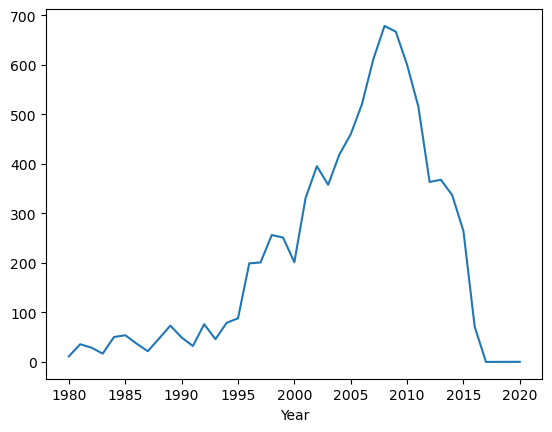

In [63]:
total_ventas_por_año['Global_Sales'].plot()

In [98]:
#Año con mayores ventas
año_max_ventas = total_ventas_por_año['Global_Sales'].idxmax()

np.int64(2008)

In [99]:
total_ventas_por_año['Global_Sales']


Year
1980     11.38
1981     35.77
1982     28.86
1983     16.79
1984     50.36
1985     53.94
1986     37.07
1987     21.74
1988     47.22
1989     73.45
1990     49.39
1991     32.23
1992     76.16
1993     45.98
1994     79.17
1995     88.11
1996    199.15
1997    200.98
1998    256.47
1999    251.27
2000    201.56
2001    331.47
2002    395.52
2003    357.85
2004    419.31
2005    459.94
2006    521.04
2007    611.13
2008    678.90
2009    667.30
2010    600.45
2011    515.99
2012    363.54
2013    368.11
2014    337.05
2015    264.44
2016     70.93
2017      0.05
2020      0.29
Name: Global_Sales, dtype: float64

#Juegos más vendidos por año
Se eliminan las filas que tienen NA en la columna Year, se agrupa por año y videojuego y se usa la función sum para sumar las ventas. 
Se usa la función idxmax para obtener el juego más vendido por año.
Se usa la funcion loc para localizar por indice el video juego más vendido por año y se ordenan por año.
Se hace una nueva columna con el año y nombre mas vendido por año para que sea el eje x en la gráfica.


In [64]:
df_juego_mas_vendidor_por_año = df.dropna(subset=['Year'])
df_juego_mas_vendidor_por_año =  df_juego_mas_vendidor_por_año.groupby(['Year','Name'])[
    ['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']
].sum().reset_index()
idx_juego_mas_vendidor_por_año = df_juego_mas_vendidor_por_año.groupby('Year')['Global_Sales'].idxmax()

top_juego_mas_vendidor_por_año = df_juego_mas_vendidor_por_año.loc[idx_juego_mas_vendidor_por_año].sort_values('Year')

top_juego_mas_vendidor_por_año['Year'] = top_juego_mas_vendidor_por_año['Year'].astype(int)
top_juego_mas_vendidor_por_año['Year_Name']=top_juego_mas_vendidor_por_año['Year'].astype(str) + ' '+ top_juego_mas_vendidor_por_año['Name']
top_juego_mas_vendidor_por_año.tail()

,Year,Name,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Year_Name
11265,2014,Call of Duty: Advanced Warfare,10.44,8.18,0.34,2.93,21.90,2014 Call of Duty: Advanced Warfare
11591,2015,Call of Duty: Black Ops 3,11.89,9.56,0.43,3.42,25.32,2015 Call of Duty: Black Ops 3
11978,2016,FIFA 17,0.50,5.48,0.07,0.85,6.91,2016 FIFA 17
12128,2017,Phantasy Star Online 2 Episode 4: Deluxe Package,0.00,0.00,0.04,0.00,0.04,2017 Phantasy Star Online 2 Episode 4: Deluxe ...
12129,2020,Imagine: Makeup Artist,0.27,0.00,0.00,0.02,0.29,2020 Imagine: Makeup Artist


Gráfica de los juegos más vendidos por año y las ventas globales

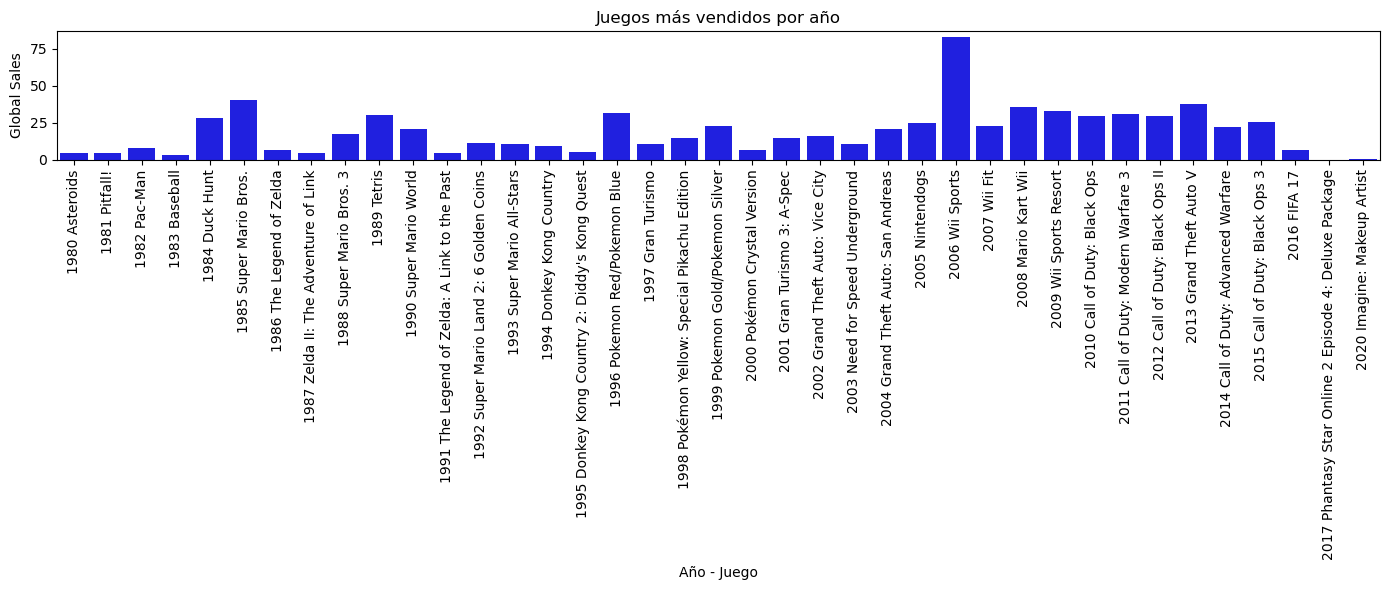

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.barplot(
    data=top_juego_mas_vendidor_por_año,
    x='Year_Name',
    y='Global_Sales',
    color='Blue' 
)

plt.xticks(rotation=90)
plt.title('Juegos más vendidos por año')
plt.xlabel('Año - Juego')
plt.ylabel('Global Sales')
plt.tight_layout()

plt.show()

Gráfica de barras apiladas de los juegos más vendidos por año y las ventas por región

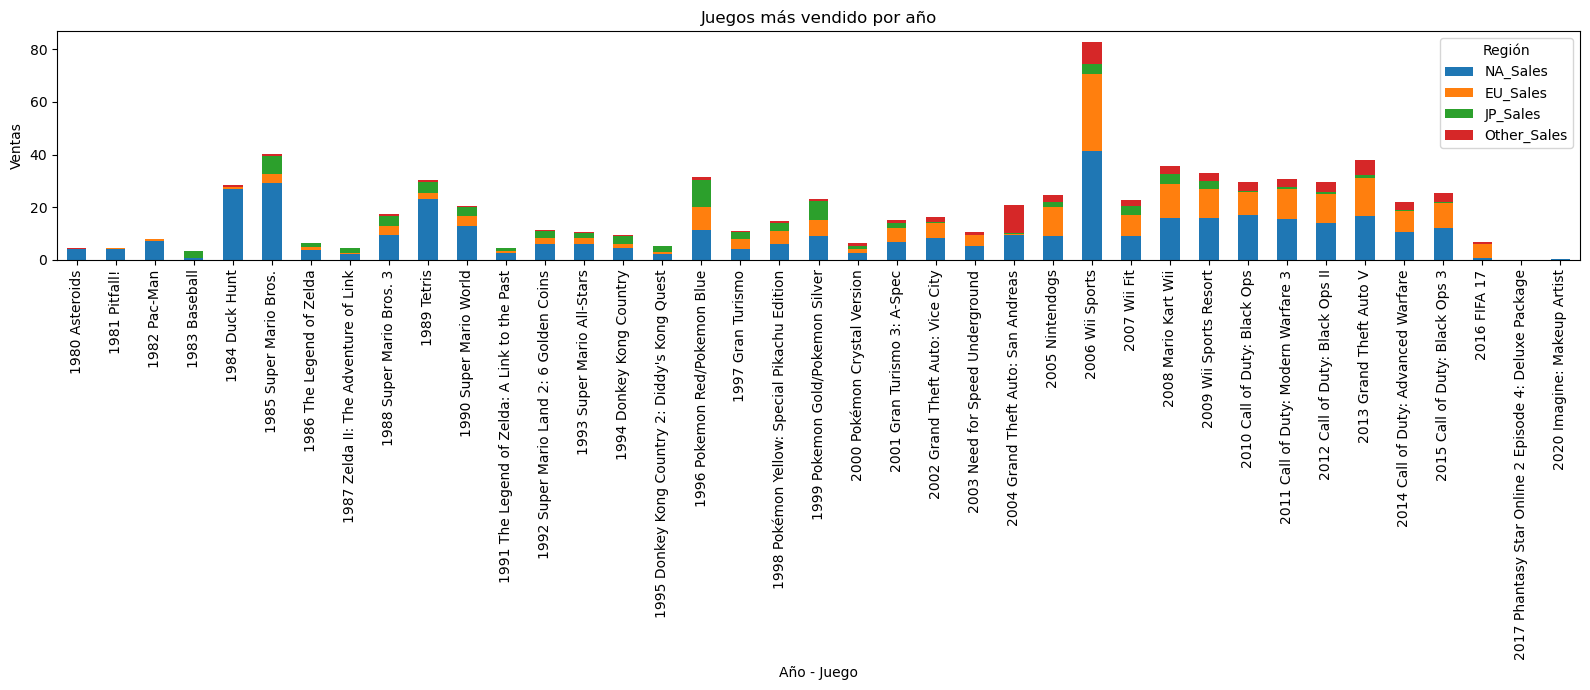

In [66]:
import matplotlib.pyplot as plt

df_plot = top_juego_mas_vendidor_por_año.set_index('Year_Name')

df_plot[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].plot(
    kind='bar',
    stacked=True,
    figsize=(16,7)
)

plt.title('Juegos más vendido por año')
plt.ylabel('Ventas')
plt.xlabel('Año - Juego')

plt.legend(title='Región')
plt.tight_layout()
plt.show()

Plataformas con más ingresos por año
Se eliminan las filas con NA en el dataframe.
Se agrupa por año y plataforma las filas y se suman las ventas.
Se usa idxmax para obtener la plataforma con más ingresos por año.
Se usa loc para obtener las filas de las plataformas con más ingresos por año.
Se convierte la columna a tipo entero (int)
Se crea la columna con el año y plataforma con más ingresos por año para la gráfica de las plataforma con más ingresos por año.


In [67]:
# Asegurar Year numérico
df_plataforma_mas_vendida_por_año = df.dropna(subset=['Year'])

# Agrupar por año y plataforma
df_plataforma_mas_vendida_por_año = df_plataforma_mas_vendida_por_año.groupby(['Year','Platform'])[
    ['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']
].sum().reset_index()

idx_plataforma_mas_vendida_por_año = df_plataforma_mas_vendida_por_año.groupby('Year')['Global_Sales'].idxmax()

top_plataforma_mas_vendida_por_año = df_plataforma_mas_vendida_por_año.loc[idx_plataforma_mas_vendida_por_año].sort_values('Year')

top_plataforma_mas_vendida_por_año.tail()
top_plataforma_mas_vendida_por_año['Year'] = top_plataforma_mas_vendida_por_año['Year'].astype(int)
top_plataforma_mas_vendida_por_año['Year_Platform']=top_plataforma_mas_vendida_por_año['Year'].astype(str) + ' '+ top_plataforma_mas_vendida_por_año['Platform']
top_plataforma_mas_vendida_por_año.tail()

,Year,Platform,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Year_Platform
213,2014,PS4,34.09,44.80,2.92,17.02,98.76,2014 PS4
223,2015,PS4,40.76,50.43,6.19,17.86,115.30,2015 PS4
233,2016,PS4,11.86,17.48,4.23,5.73,39.25,2016 PS4
238,2017,PS4,0.00,0.00,0.03,0.00,0.03,2017 PS4
240,2020,DS,0.27,0.00,0.00,0.02,0.29,2020 DS


Gráfica de barras apiladas de las ventas por region de las plataformas con más ingresos por año

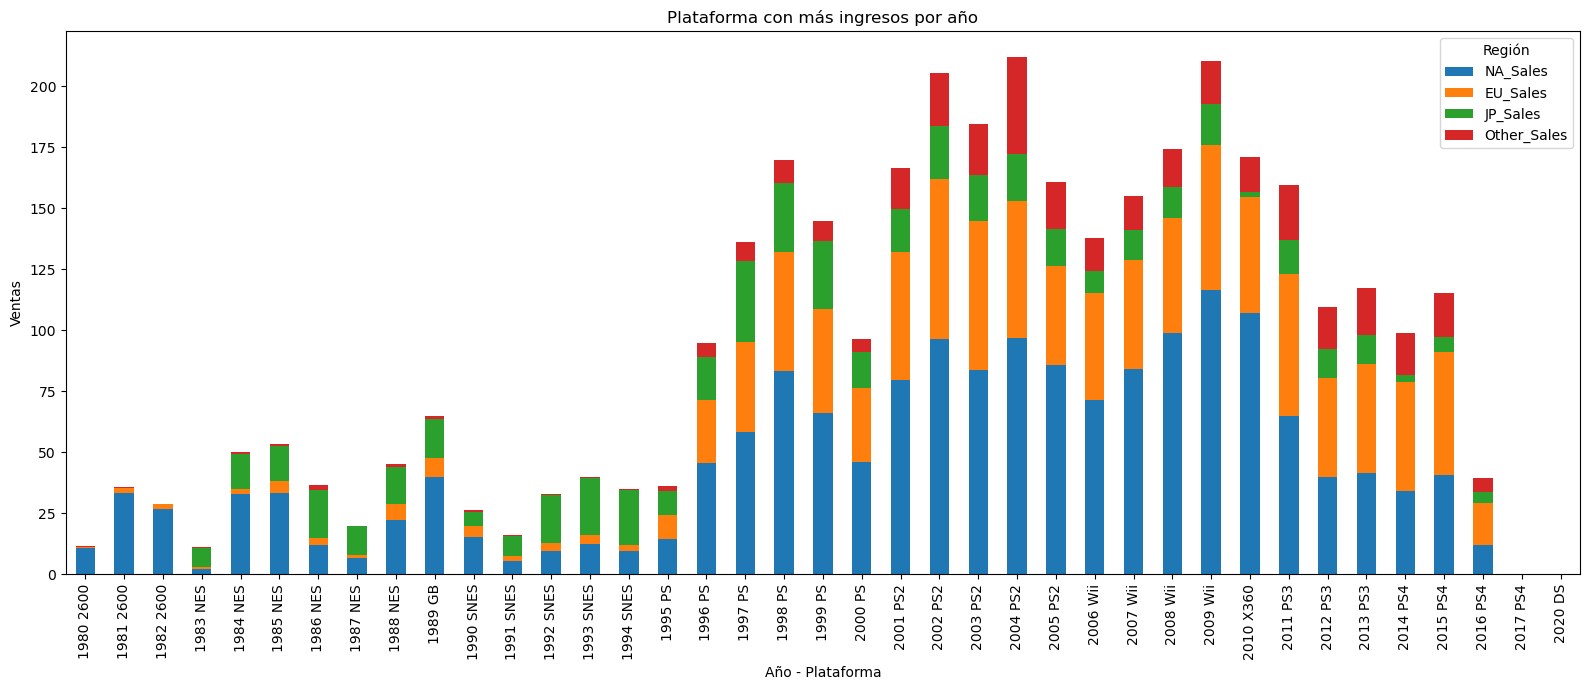

In [68]:
import matplotlib.pyplot as plt

df_plot = top_plataforma_mas_vendida_por_año.set_index('Year_Platform')

df_plot[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].plot(
    kind='bar',
    stacked=True,
    figsize=(16,7)
)

plt.title('Plataforma con más ingresos por año')
plt.ylabel('Ventas')
plt.xlabel('Año - Plataforma')

plt.legend(title='Región')
plt.tight_layout()
plt.show()

Gráfico de comparación de ventas entre géneros por año
Se elimina las filas con NA en la columna Year.
Se convierte la columna Year a tipo entero (Int64)
Se agrupa las ventas por año y por género.

In [69]:
 #Gráfico de comparación de ventas entre géneros por año
#df.sample()
df_ventas_genero_año = df.dropna(subset=['Year'])
df_ventas_genero_año['Year'] = df_ventas_genero_año['Year'].astype('Int64')
df_ventas_genero_año = df_ventas_genero_año.groupby(['Year','Genre'])[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].sum().reset_index()
df_ventas_genero_año

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3742/3266653118.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ventas_genero_año['Year'] = df_ventas_genero_año['Year'].astype('Int64')


,Year,Genre,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1980,Action,0.32,0.02,0.00,0.00,0.34
1,1980,Fighting,0.72,0.04,0.00,0.01,0.77
2,1980,Misc,2.53,0.15,0.00,0.02,2.71
3,1980,Shooter,6.56,0.43,0.00,0.08,7.07
4,1980,Sports,0.46,0.03,0.00,0.01,0.49
...,...,...,...,...,...,...,...
384,2016,Sports,4.57,7.36,0.78,1.92,14.60
385,2016,Strategy,0.11,0.32,0.05,0.04,0.50
386,2017,Action,0.00,0.00,0.01,0.00,0.01
387,2017,Role-Playing,0.00,0.00,0.04,0.00,0.04


Gráfica de comparación de ventas globales entre Géneros por año

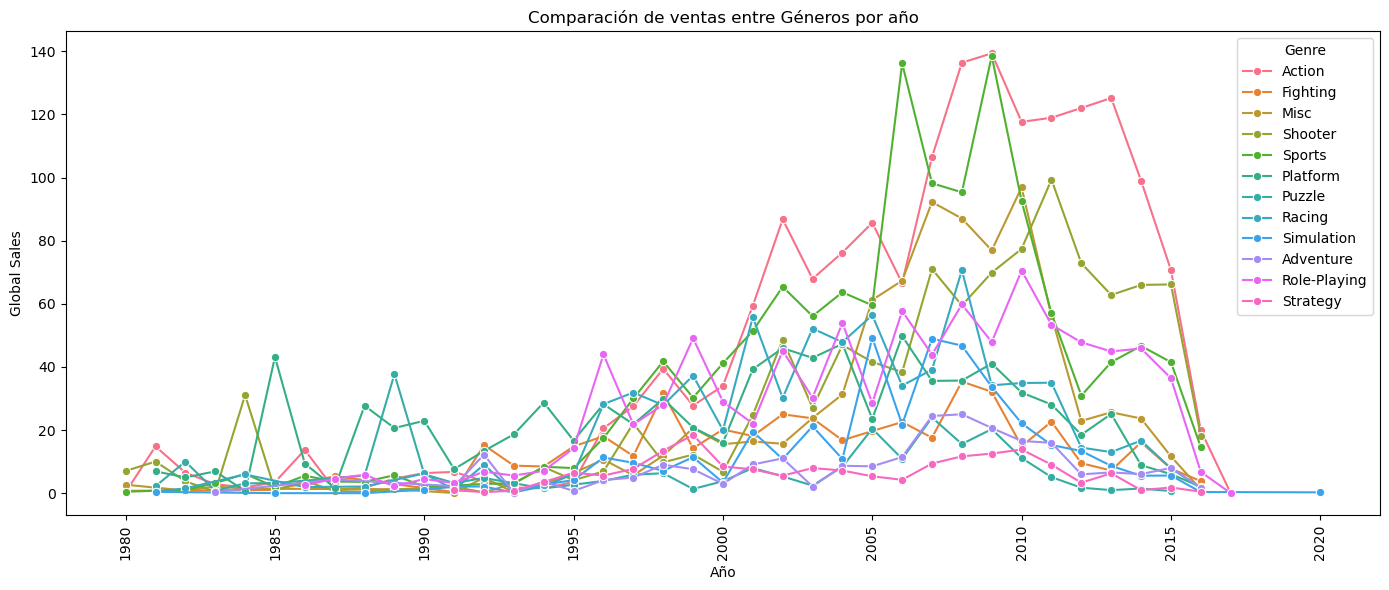

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df_ventas_genero_año,
    x='Year',
    y='Global_Sales',
    hue='Genre',
    marker='o'
    
)

plt.xticks(rotation=90)
plt.title('Comparación de ventas entre Géneros por año')
plt.xlabel('Año')
plt.ylabel('Global Sales')
plt.tight_layout()

plt.show()

Gráfica de área apilada de comparacion de ventas entre Géneros por año

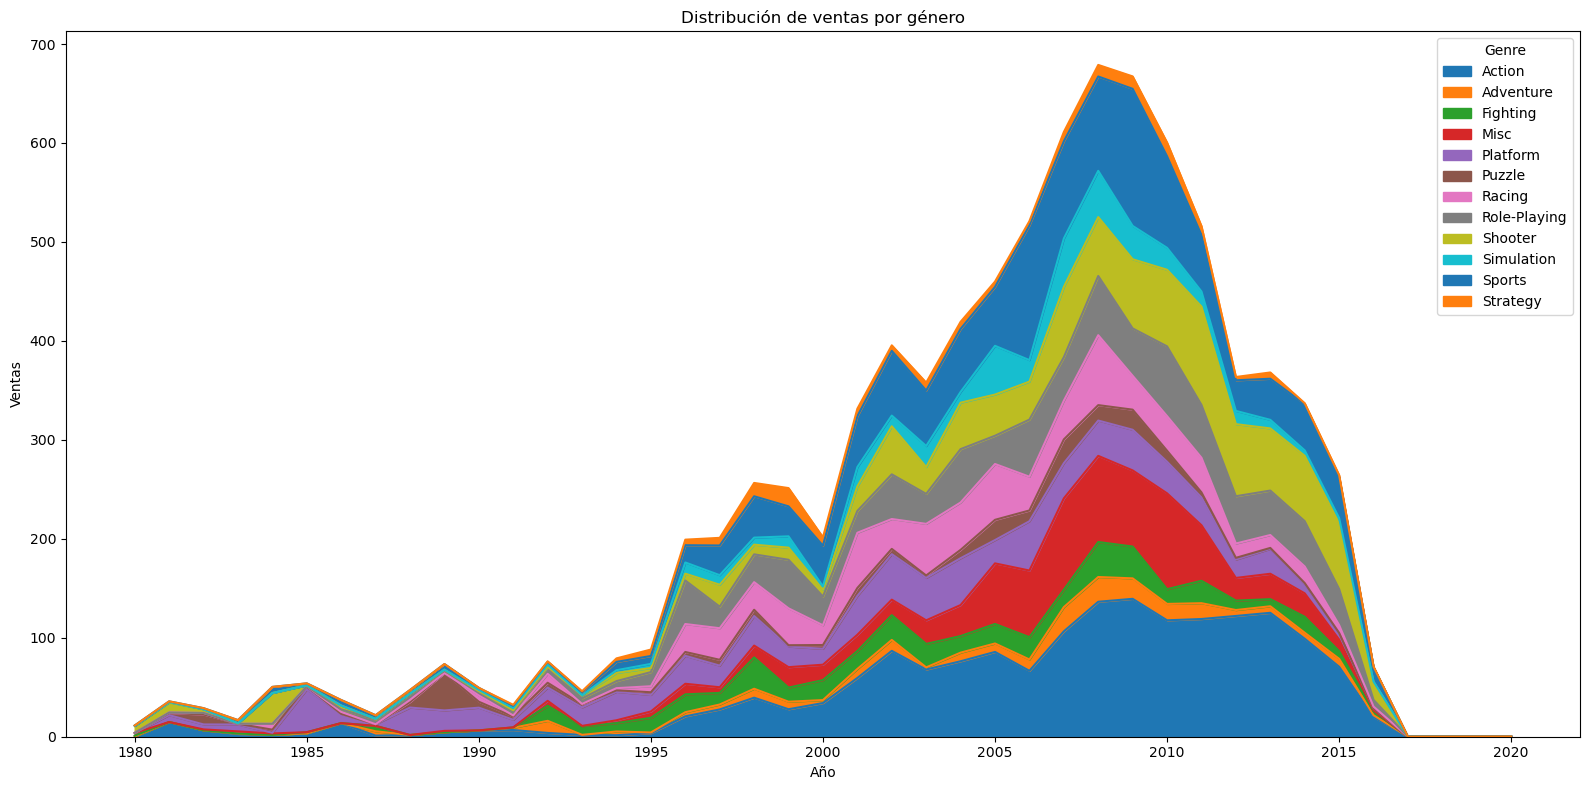

In [71]:
df_pivot = df_ventas_genero_año.pivot(
    index='Year',
    columns='Genre',
    values='Global_Sales'
).fillna(0)

df_pivot.plot(kind='area', stacked=True, figsize=(16,8))

plt.title('Distribución de ventas por género')
plt.xlabel('Año')
plt.ylabel('Ventas')
plt.tight_layout()
plt.show()

Dado que la gráfica anterior tiene muchas líneas, se presenta una gráfica con los 5 géneros con más ventas globales

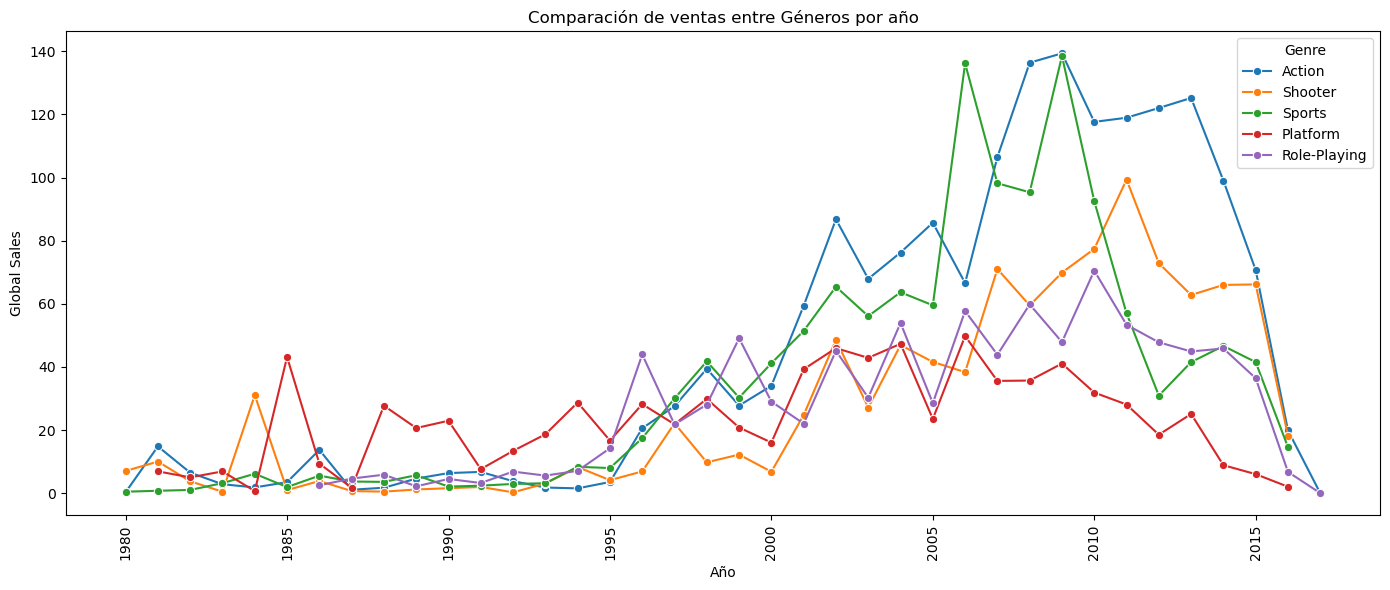

In [72]:
top_genres = df.groupby('Genre')['Global_Sales'].sum().nlargest(5).index

df_ventas_genero_año = df_ventas_genero_año[
    df_ventas_genero_año['Genre'].isin(top_genres)
]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df_ventas_genero_año,
    x='Year',
    y='Global_Sales',
    hue='Genre',
    marker='o'
    
)

plt.xticks(rotation=90)
plt.title('Comparación de ventas entre Géneros por año')
plt.xlabel('Año')
plt.ylabel('Global Sales')
plt.tight_layout()

plt.show()

Se hace un heatmap de las ventas globales por género y año para visualizar mejor cual género y en que año se tiene mayor ventas.


<Axes: xlabel='Year', ylabel='Genre'>

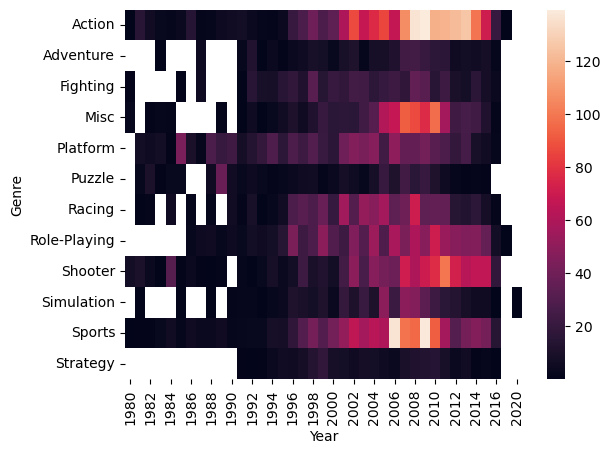

In [73]:
pivot = df.pivot_table(values='Global_Sales', index='Genre', columns='Year', aggfunc='sum')
sns.heatmap(pivot)

Gráfica de las ventas

<Axes: title={'center': 'Participación de ventas por región a lo largo del tiempo'}, xlabel='Year'>

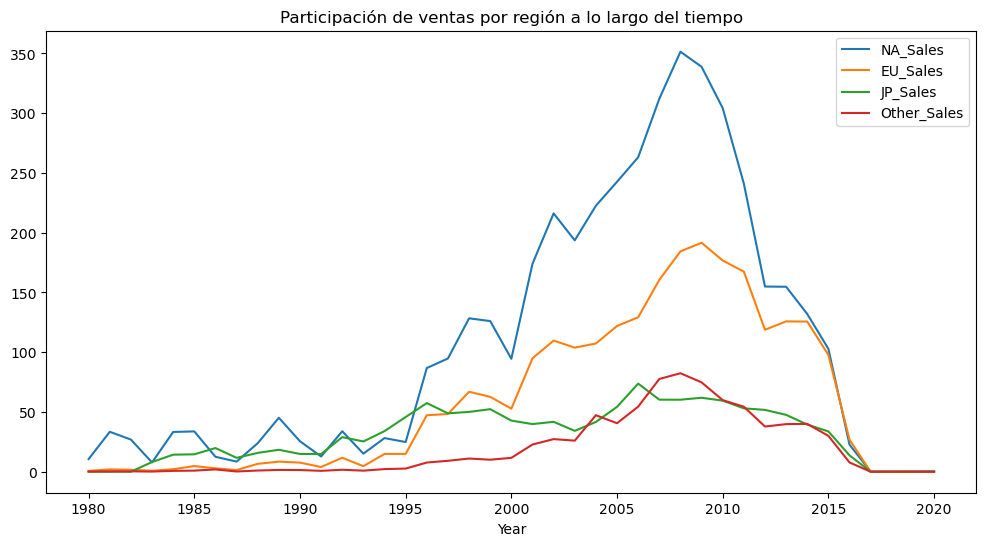

In [74]:
df_region = df.groupby('Year')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
df_region.plot(kind='line', figsize=(12,6), title='Participación de ventas por región a lo largo del tiempo')



Gráfica de los videojuegos en el top 10.

<Axes: title={'center': 'Top 10 juegos'}, xlabel='Name'>

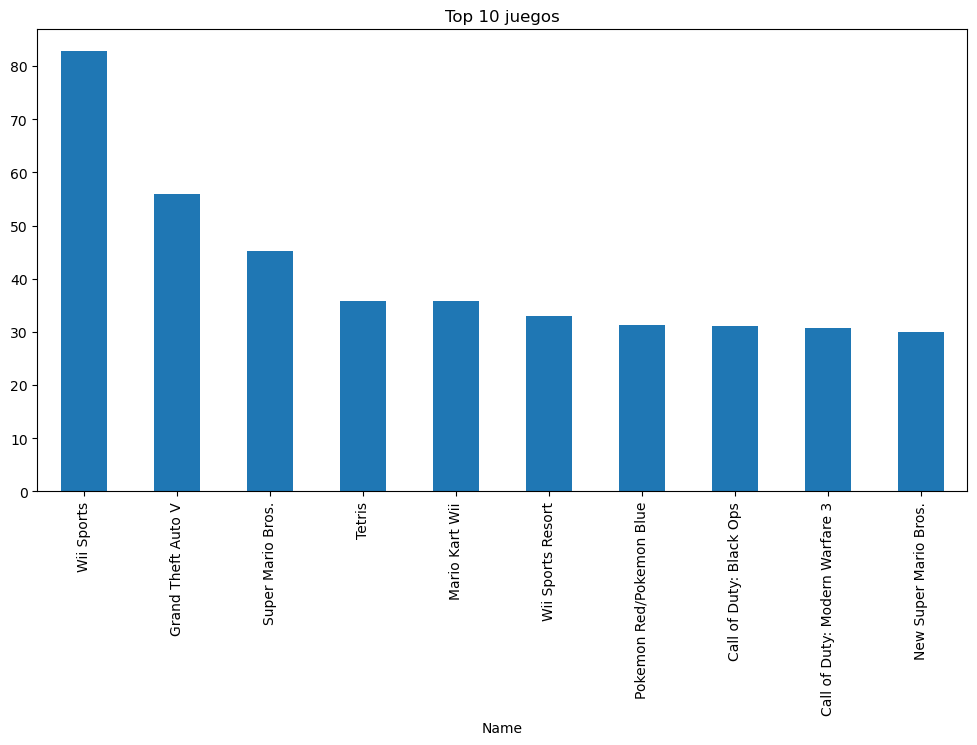

In [75]:
top10 = df.groupby('Name')['Global_Sales'].sum().sort_values(ascending=False).head(10)

top10.plot(kind='bar', figsize=(12,6), title='Top 10 juegos')

Comparación de las videojuegos en el top 10 contra el resto del mercado.

Los 10 videojuegos representan el 4.62% del mercado


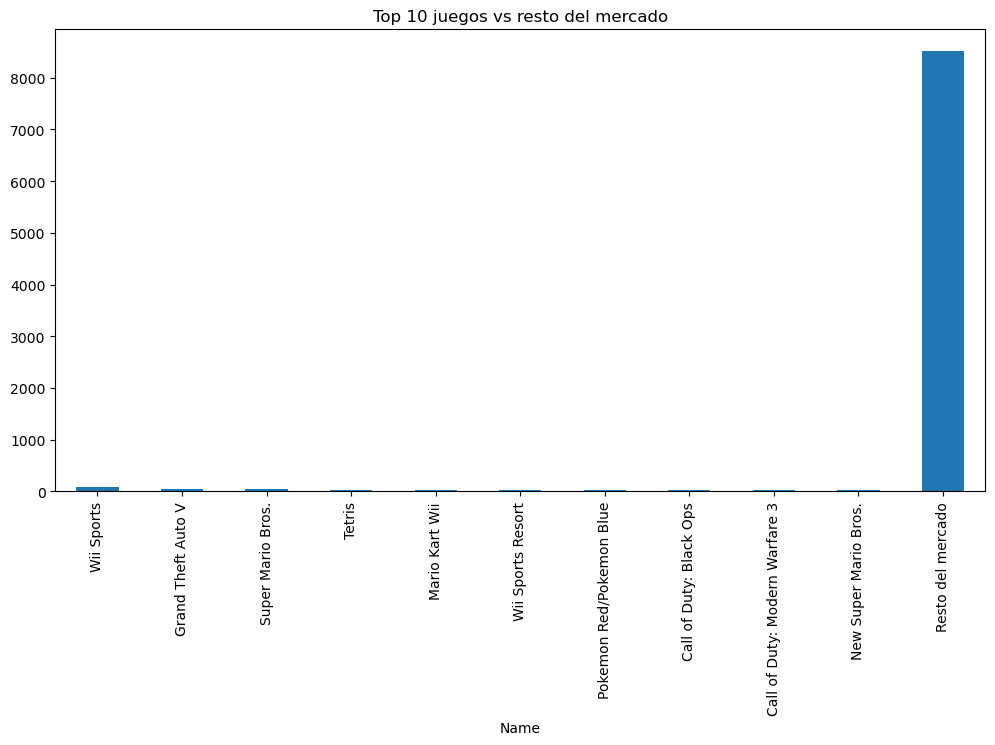

In [76]:
top10 = df.groupby('Name')['Global_Sales'].sum().sort_values(ascending=False).head(10)
resto = df['Global_Sales'].sum() - top10.sum()

top10['Resto del mercado'] = resto
top10.plot(kind='bar', figsize=(12,6), title='Top 10 juegos vs resto del mercado')

total = df['Global_Sales'].sum()
top10_sum = total - resto
porcentaje = (top10_sum / total) * 100
print(f'Los 10 videojuegos representan el {porcentaje:.2f}% del mercado')

Crecimiento:
1) qué género ha tenido el mayor y menor crecimiento,
2) qué plataforma ha tenido el mayor y menor crecimiento,
3) qué videojuego ha tenido el mayor y menor crecimiento
2 elementos adicionales que muestren oportunidades de mercado

In [77]:
df.sample(1)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
390,391,Spider-Man 2,PS2,2004,Action,Activision,1.75,1.2,0.02,0.43,3.41


Qué género ha tenido el mayor y menor crecimiento
Se agrupa por Género y por año y se suman las ventas. 
Se obtiene la tabla pivote con este dataframe.

In [78]:
genre_year = df.groupby(['Genre','Year'])['Global_Sales'].sum().reset_index()
pivot = genre_year.pivot(index='Genre',columns='Year',values='Global_Sales')

In [79]:
pivot.head()

Year,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020
Genre,,,,,,,,,,,,,,,,,,,,,
Action,0.34,14.84,6.52,2.86,1.85,3.52,13.74,1.12,1.75,4.64,...,139.36,117.64,118.96,122.04,125.22,99.02,70.70,19.91,0.01,NaN
Adventure,NaN,NaN,NaN,0.40,NaN,NaN,NaN,4.38,NaN,NaN,...,20.68,16.57,15.98,5.99,6.61,6.06,8.03,1.81,NaN,NaN
Fighting,0.77,NaN,NaN,NaN,NaN,1.05,NaN,5.42,NaN,NaN,...,32.15,14.89,22.68,9.51,7.21,16.15,7.78,3.86,NaN,NaN
Misc,2.71,NaN,0.87,2.14,1.45,NaN,NaN,NaN,NaN,1.28,...,76.94,96.86,56.08,22.92,25.65,23.68,11.69,1.17,NaN,NaN
Platform,NaN,6.93,5.03,6.93,0.69,43.17,9.39,1.74,27.73,20.66,...,41.09,31.90,28.11,18.55,25.12,8.89,6.05,2.07,NaN,NaN


Se obtiene el crecimiento por año usando la función pct_change.

In [80]:
crecimiento = pivot.pct_change(axis=1)
crecimiento

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3742/3961002503.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  crecimiento = pivot.pct_change(axis=1)


Year,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020
Genre,,,,,,,,,,,,,,,,,,,,,
Action,NaN,42.647059,-0.560647,-0.561350,-0.353147,0.902703,2.903409,-0.918486,0.562500,1.651429,...,0.021776,-0.155855,0.011221,0.025891,0.026057,-0.209232,-0.286003,-0.718388,-0.999498,0.00000
Adventure,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,9.950000,0.000000,0.000000,...,-0.173461,-0.198743,-0.035607,-0.625156,0.103506,-0.083207,0.325083,-0.774595,0.000000,0.00000
Fighting,NaN,0.000000,0.000000,0.000000,0.000000,0.363636,0.000000,4.161905,0.000000,0.000000,...,-0.091295,-0.536858,0.523170,-0.580688,-0.241851,1.239945,-0.518266,-0.503856,0.000000,0.00000
Misc,NaN,0.000000,-0.678967,1.459770,-0.322430,0.000000,0.000000,0.000000,0.000000,-0.117241,...,-0.115937,0.258903,-0.421020,-0.591298,0.119110,-0.076803,-0.506334,-0.899914,0.000000,0.00000
Platform,NaN,NaN,-0.274170,0.377734,-0.900433,61.565217,-0.782488,-0.814696,14.936782,-0.254959,...,0.150980,-0.223655,-0.118809,-0.340092,0.354178,-0.646099,-0.319460,-0.657851,0.000000,0.00000
Puzzle,NaN,NaN,3.477679,-0.922233,3.025641,0.022293,0.000000,0.000000,0.738318,5.765233,...,0.302758,-0.449532,-0.542934,-0.655577,-0.437500,0.515152,-0.533333,0.000000,0.000000,0.00000
Racing,NaN,NaN,2.270833,0.000000,2.789809,0.000000,-0.670588,0.000000,0.091837,0.000000,...,-0.516134,0.021644,0.002290,-0.586975,-0.098202,0.279908,-0.525464,-0.792929,0.000000,0.00000
Role-Playing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.845238,0.264516,-0.625850,...,-0.199398,0.472234,-0.243193,-0.104178,-0.060448,0.020926,-0.205408,-0.814490,-0.994083,0.00000
Shooter,NaN,0.420085,-0.622510,-0.873351,63.791667,-0.967846,2.890000,-0.817481,-0.281690,1.352941,...,0.174424,0.107598,0.283555,-0.266707,-0.138073,0.050955,0.002273,-0.724565,0.000000,0.00000


Se obtiene el crecimiento de los últimos cuatro años.

In [81]:
last_years = pivot.columns.sort_values()[-4:]
crecimiento = crecimiento[last_years]
crecimiento

Year,2015,2016,2017,2020
Genre,,,,
Action,-0.286003,-0.718388,-0.999498,0.00000
Adventure,0.325083,-0.774595,0.000000,0.00000
Fighting,-0.518266,-0.503856,0.000000,0.00000
Misc,-0.506334,-0.899914,0.000000,0.00000
Platform,-0.319460,-0.657851,0.000000,0.00000
Puzzle,-0.533333,0.000000,0.000000,0.00000
Racing,-0.525464,-0.792929,0.000000,0.00000
Role-Playing,-0.205408,-0.814490,-0.994083,0.00000
Shooter,0.002273,-0.724565,0.000000,0.00000


Se usa la función mean para sacar el cambio porcentual promedio de los últimos 4 años y la funcion idxmax y idxmin para sacar el género con mayor crecimiento y menor crecimiento respectivamente. 

In [82]:
crecimiento_total = crecimiento.mean(axis=1)
mayor_crecimiento = crecimiento_total.idxmax()
menor_crecimiento = crecimiento_total.idxmin()

print("Mayor crecimiento:", mayor_crecimiento)
print("Menor crecimiento:", menor_crecimiento)

Mayor crecimiento: Strategy
Menor crecimiento: Role-Playing


Gráfica de crecimiento por género de los últimos 4 años

<Axes: title={'center': 'Crecimiento por género (últimos 4 años)'}, ylabel='Genre'>

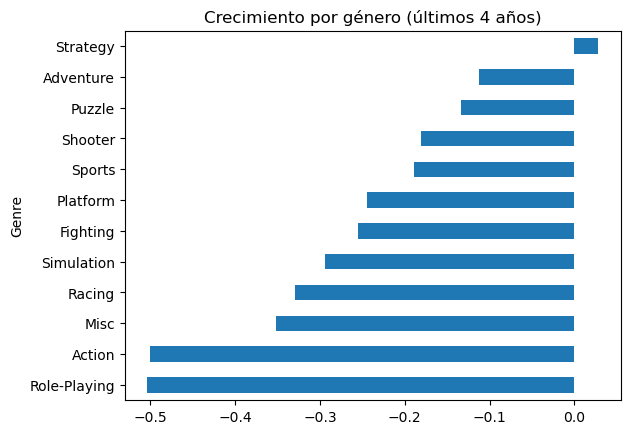

In [83]:
crecimiento_total.sort_values().plot(
    kind='barh',
    title='Crecimiento por género (últimos 4 años)'
)

El género Strategy presenta el mayor crecimiento puntual (83.8% en 2015), aunque no mantiene una tendencia positiva sostenida en los años siguientes.
Role-Playing muestra las mayores caídas, especialmente en 2017 (-99.4%), lo que indica una fuerte contracción en sus ventas. En general, la mayoría de los géneros presentan tendencias negativas o sin cambios (posiblemente por falta de datos), lo cual podría deberse a una disminución global en el mercado.

2) qué plataforma ha tenido el mayor y menor crecimiento

Se agrupa el dataframe por Plataforma y año y se suman las ventas globales.
Se obtiene la tabla pivote del dataframe anterior.

In [84]:
df_platform_year = df.groupby(['Platform','Year'])['Global_Sales'].sum().reset_index()
pivot_platform = df_platform_year.pivot(index='Platform',columns='Year',values='Global_Sales')

Se obtiene el crecimiento usando la función pct_change de los últimos cuatro años.

In [85]:
last_years = pivot_platform.columns.sort_values()[-4:]
crecimiento_platform = pivot_platform.pct_change(axis=1)
crecimiento_platform = crecimiento_platform[last_years]
crecimiento_platform

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3742/2993718063.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  crecimiento_platform = pivot_platform.pct_change(axis=1)


Year,2015,2016,2017,2020
Platform,,,,
2600,0.000000,0.000000,0.000000,0.0
3DO,0.000000,0.000000,0.000000,0.0
3DS,-0.374363,-0.755465,0.000000,0.0
DC,0.000000,0.000000,0.000000,0.0
DS,0.000000,0.000000,0.000000,13.5
GB,0.000000,0.000000,0.000000,0.0
GBA,0.000000,0.000000,0.000000,0.0
GC,0.000000,0.000000,0.000000,0.0
GEN,0.000000,0.000000,0.000000,0.0


Se obtiene el mayor y menor crecimiento promediando el cambio porcentual de los últimos 4 años.

In [86]:
crecimiento_total_platform=  crecimiento_platform.mean(axis=1)
mayor_crecimiento_platform = crecimiento_total_platform.idxmax()
menor_crecimiento_platform = crecimiento_total_platform.idxmin()

print("Mayor crecimiento:", mayor_crecimiento_platform)
print("Menor crecimiento:", menor_crecimiento_platform)

Mayor crecimiento: DS
Menor crecimiento: PSV


Gráfica de crecimiento de las ventas de plataformas en los últimos 4 años:
La plataforma DS presenta el mayor crecimiento en el último año analizado (2020), con un incremento de 135%, mientras que en los años anteriores no se observan variaciones, posiblemente debido a la ausencia de datos.
Por otro lado, PSV muestra una tendencia negativa, alcanzando su mayor caída en 2017 con aproximadamente -99.41%, lo que indica una contracción casi total en sus ventas.

<Axes: title={'center': 'Crecimiento por plataforma (últimos 4 años)'}, ylabel='Platform'>

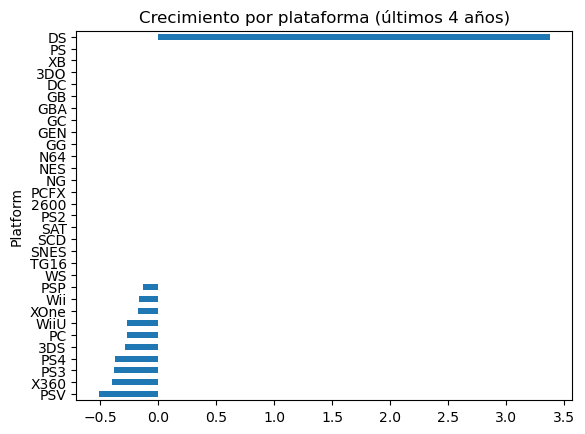

In [87]:
crecimiento_total_platform.sort_values().plot(
    kind='barh',
    title='Crecimiento por plataforma (últimos 4 años)'
)

3) qué videojuego ha tenido el mayor y menor crecimiento
Se agrupa por videojuego y año y se suma las ventas globales.
Se saca la tabla pivote del dataframe anterior.
Se obtiene los 4 últimos años con datos.
Se calcula el cambio porcentual de los últimos 4 años con datos.


In [88]:
df_videojuego_year = df.groupby(['Name','Year'])['Global_Sales'].sum().reset_index()
pivot_videojuego = df_videojuego_year.pivot(index='Name',columns='Year',values='Global_Sales')

Se obtiene los últimos 4 años con datos y se calcucla el cambio porcentual de cada año.

In [89]:
lastyears = pivot_videojuego.columns.sort_values()[-4:]
crecimiento_videojuego = pivot_videojuego.pct_change(axis=1)
crecimiento_videojuego = crecimiento_videojuego[last_years]

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_3742/3857325698.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  crecimiento_videojuego = pivot_videojuego.pct_change(axis=1)


El videojuego con mayor y menor crecimiento se obtiene calculando el promedio del cambio porcentual de los últimos años.

In [90]:
crecimiento_total_videojuego =  crecimiento_videojuego.mean(axis=1)
mayor_crecimiento_videojuego = crecimiento_total_videojuego.idxmax()
menor_crecimiento_videojuego = crecimiento_total_videojuego.idxmin()

print("Mayor crecimiento:", mayor_crecimiento_videojuego)
print("Menor crecimiento:", menor_crecimiento_videojuego)

Mayor crecimiento: Divinity: Original Sin
Menor crecimiento: Need for Speed (2015)


In [91]:
#crecimiento_total_videojuego.sort_values().plot(
#    kind='barh',
#    title='Crecimiento por videojuego (últimos 4 años)'
#)

El videojuego con mayor crecimiento en los últimos 4 años con datos es Divinity: Original Sin, el cual obtuvo su mayor incremento en el año 2015 con un 160%. En los años siguientes, no presentó crecimiento o no se dispone de datos.
Por otro lado, Need for Speed (2015) registró la mayor caída en el año 2016, con un -99.02%. En los años posteriores, no hay datos disponibles o no presentó crecimiento.

In [92]:
#2 elementos adicionales que muestren oportunidades de mercado

#La falta de crecimiento en plataformas antiguas indica que los usuarios migran hacia plataformas modernas con el tiempo. Es importante enfocar la atención en plataformas modernas y activas.
#Los videojuegos y los géneros no presentan un crecimiento sostenido, lo que indica que los usuarios cambian constantemente de plataformas, videojuegos y géneros.

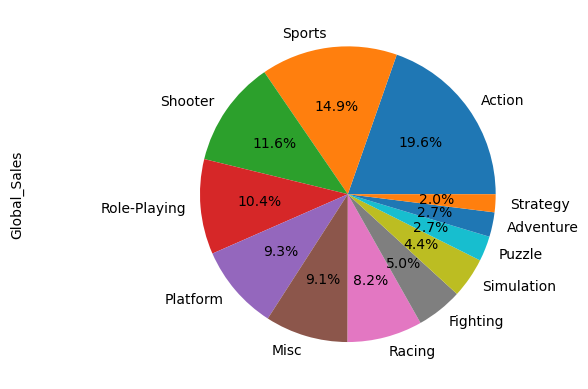

In [97]:
import matplotlib.pyplot as plt

ventas_genero = df.groupby('Genre')['Global_Sales'].sum()
market_share = (ventas_genero / ventas_genero.sum()).sort_values(ascending=False)

ax = market_share.plot.pie(autopct='%1.1f%%')

ax.set_ylabel('Global_Sales', labelpad=100)  # 👈 increase space here

plt.show()

In [94]:
top10 = df.groupby('Name')['Global_Sales'].sum().sort_values(ascending=False).head(10)
resto = df.groupby('Name')['Global_Sales'].sum().sort_values(ascending=False).iloc[10:]

participacion_top10 = top10.sum() / (top10.sum() + resto.sum()) * 100
print(f'El mercado está dominado por pocos juegos: {participacion_top10:.2f}%')

El mercado está dominado por pocos juegos: 4.62%
